In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

%matplotlib inline
plt.style.use('fivethirtyeight')

df = pd.read_csv('https://raw.githubusercontent.com/datasets/covid-19/main/data/countries-aggregated.csv', parse_dates=['Date'])
df['Total Cases'] = df[['Confirmed', 'Recovered', 'Deaths']].sum(axis=1)

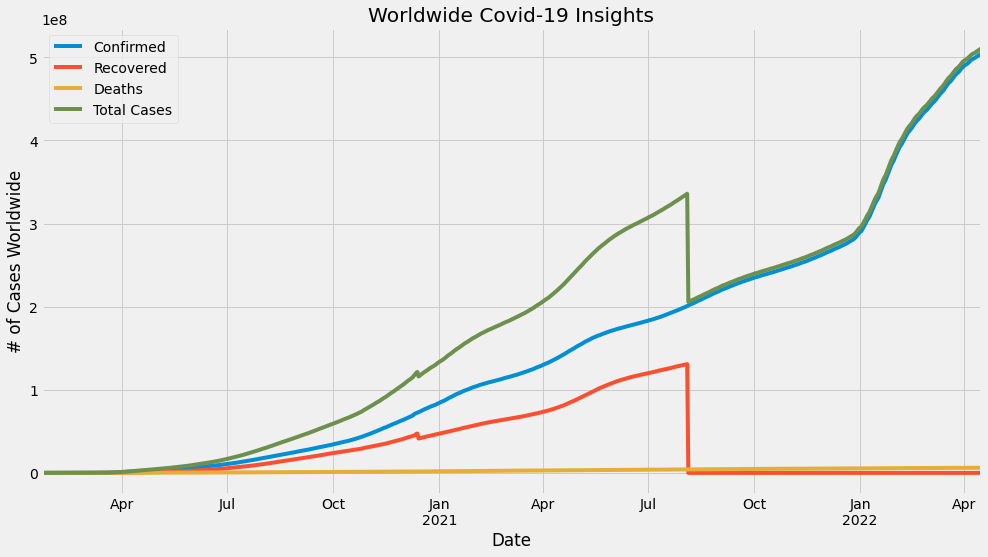

In [14]:
# Worldwide Cases

worldwide_df = df.groupby(['Date']).sum()
w = worldwide_df.plot(figsize=(15,8))
w.set_xlabel('Date')
w.set_ylabel('# of Cases Worldwide')
w.title.set_text('Worldwide Covid-19 Insights')

plt.show()

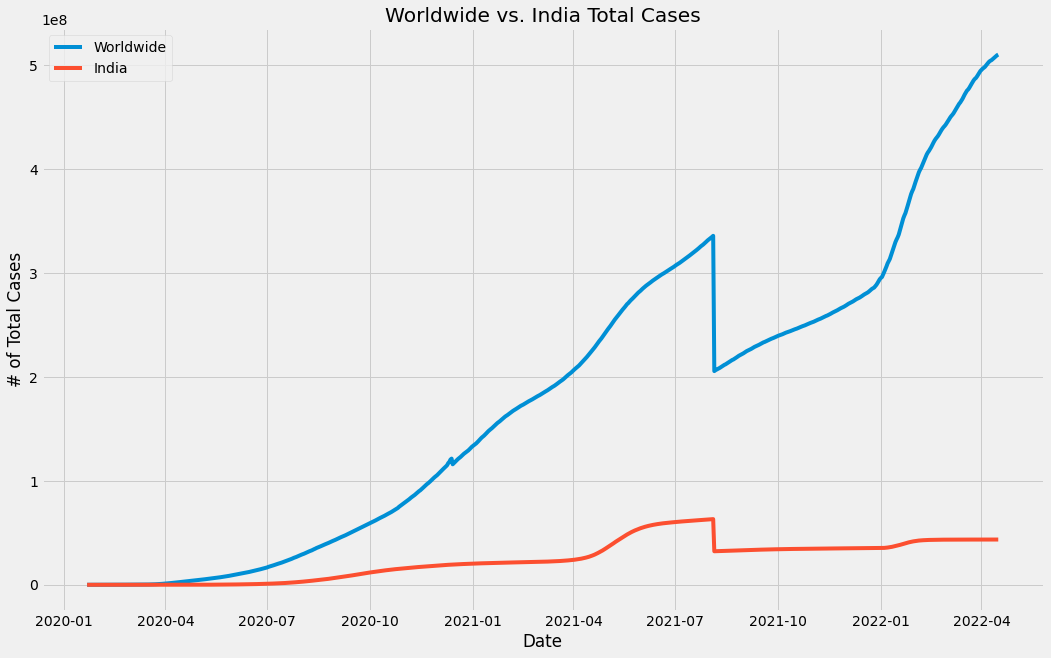

In [29]:
# Worldwide vs. United States Total Cases

us_df = df[df['Country']=='India'].groupby(['Date']).sum()

fig = plt.figure(figsize=(16,10))
ax = fig.add_subplot(111)

ax.plot(worldwide_df[['Total Cases']],label='Worldwide')
ax.plot(us_df[['Total Cases']],label='India')
ax.set_xlabel('Date')
ax.set_ylabel('# of Total Cases')
ax.title.set_text('Worldwide vs. India Total Cases')
plt.legend(loc='upper left')
plt.show()

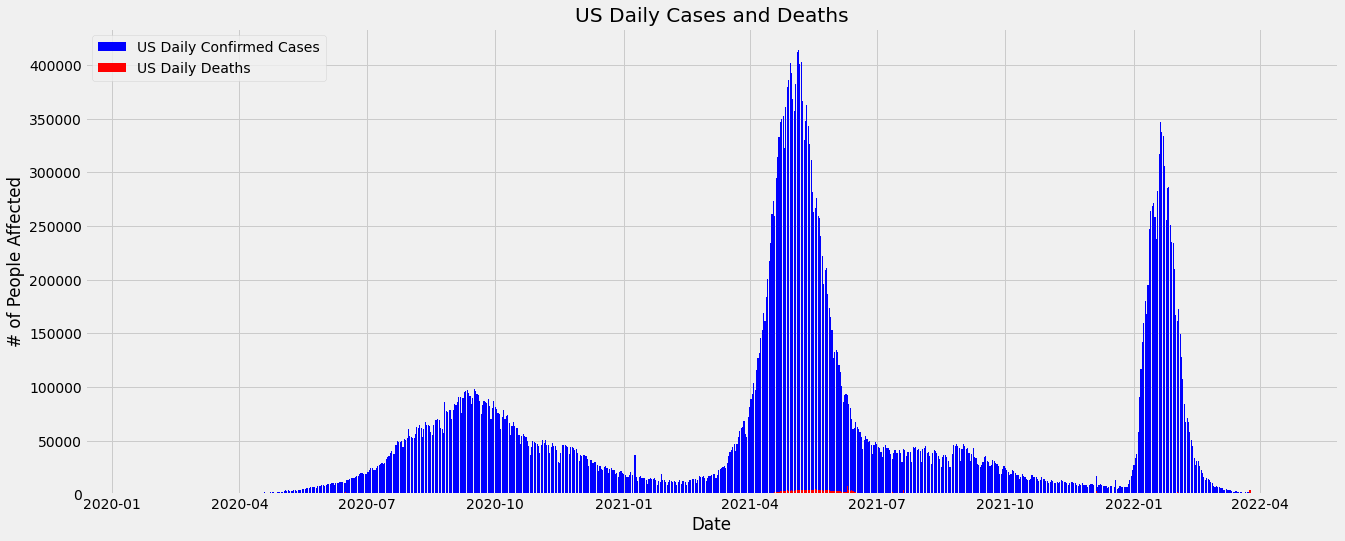

In [16]:
# United States Daily Cases and Deaths
us_df = us_df.reset_index()
us_df['Daily Confirmed'] = us_df['Confirmed'].sub(us_df['Confirmed'].shift())
us_df['Daily Deaths'] = us_df['Deaths'].sub(us_df['Deaths'].shift())

fig = plt.figure(figsize=(20,8))
ax = fig.add_subplot(111)

ax.bar(us_df['Date'],us_df['Daily Confirmed'],color='b',label='US Daily Confirmed Cases')
ax.bar(us_df['Date'],us_df['Daily Deaths'],color='r',label='US Daily Deaths')
ax.set_xlabel('Date')
ax.set_ylabel('# of People Affected')
ax.title.set_text('US Daily Cases and Deaths')

plt.legend(loc='upper left')
plt.show()

In [3]:
from datetime import date, timedelta
yesterday = date.today() - timedelta(days=1)
yesterday.strftime('%Y-%m-%d')

today_df = df[df['Date']==yesterday]
top_10 = today_df.sort_values(['Confirmed'], ascending=False)[:10]
top_10.head()

,Date,Country,Confirmed,Recovered,Deaths,Total Cases
